# Team Behavior Validation

This notebook validates team behavior through visualization of:
1. Network structure
2. Performance evolution
3. Agent interactions
4. Network metrics

In [7]:
import sys
sys.path.append('..')

import numpy as np
from models.team import Team
from analysis.visualization.figures import plot_team_snapshot, visualize_team_evolution
import matplotlib.pyplot as plt
from IPython import display
%matplotlib inline

## Create Test Teams

Create teams with different network structures to visualize behavior:

In [8]:
# Base team parameters
base_params = {
    'team_size': 8,
    'agent_num_vars': 2,  # Each agent controls 2 variables
    'team_graph_type': 'complete',
    'team_graph_opts': None,
    'fn_type': 'sin2',
    'fn_opts': {'weight': 'node', 'frequency': 'uniform'},
    'agent_optim_type': 'nelder_mead',
    'agent_optim_opts': None,
    'agent_steplim': 0.01
}

# Create teams with different configurations
teams = {
    'complete': Team(**base_params),
    'star': Team(**{**base_params, 'team_graph_type': 'star'}),
    'small_world': Team(**{**base_params, 
                          'team_graph_type': 'small_world',
                          'team_graph_opts': {'k': 2, 'p': 0.1},
                          'team_size': 8})
}

## Initial Network States

Visualize initial network structure and performance for each team type:


=== COMPLETE TEAM ===
Number of nodes: 8
Number of edges: 28
Initial performance: nan
Network metrics:
  team_graph_centrality_degree_mean: 1.000
  team_graph_centrality_degree_stdev: 0.000
  team_graph_centrality_betweenness_mean: 0.000
  team_graph_centrality_betweenness_stdev: 0.000
  team_graph_centrality_eigenvector_mean: 0.354
  team_graph_centrality_eigenvector_stdev: 0.000
  team_graph_nearest_neighbor_degree_mean: 1.000
  team_graph_nearest_neighbor_degree_stdev: 0.000
  team_graph_clustering: 1.000
  team_graph_density: 1.000
  team_graph_assortativity: 0.000
  team_graph_pathlength: 1.000
  team_graph_diameter: 1.000


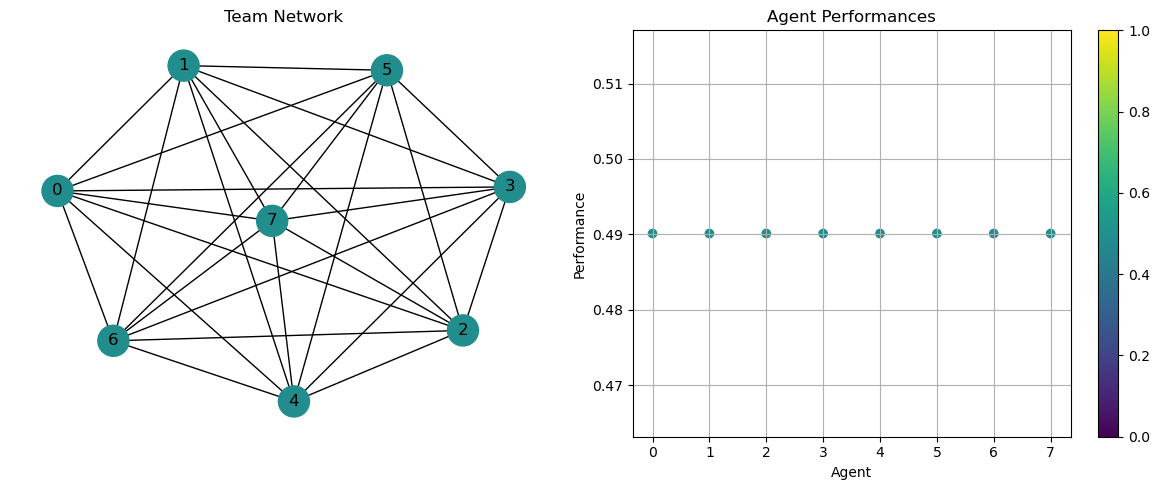


=== STAR TEAM ===
Number of nodes: 8
Number of edges: 7
Initial performance: nan
Network metrics:
  team_graph_centrality_degree_mean: 0.250
  team_graph_centrality_degree_stdev: 0.303
  team_graph_centrality_betweenness_mean: 0.125
  team_graph_centrality_betweenness_stdev: 0.354
  team_graph_centrality_eigenvector_mean: 0.322
  team_graph_centrality_eigenvector_stdev: 0.155
  team_graph_nearest_neighbor_degree_mean: 0.893
  team_graph_nearest_neighbor_degree_stdev: 0.303
  team_graph_clustering: 0.000
  team_graph_density: 0.250
  team_graph_assortativity: -1.000
  team_graph_pathlength: 1.750
  team_graph_diameter: 2.000


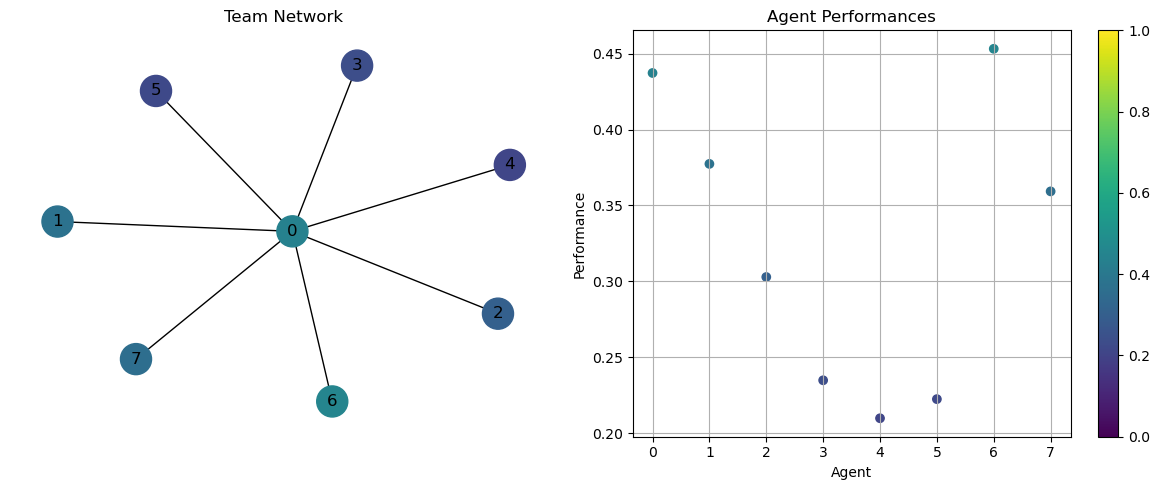


=== SMALL_WORLD TEAM ===
Number of nodes: 8
Number of edges: 8
Initial performance: nan
Network metrics:
  team_graph_centrality_degree_mean: 0.286
  team_graph_centrality_degree_stdev: 0.076
  team_graph_centrality_betweenness_mean: 0.232
  team_graph_centrality_betweenness_stdev: 0.220
  team_graph_centrality_eigenvector_mean: 0.331
  team_graph_centrality_eigenvector_stdev: 0.131
  team_graph_nearest_neighbor_degree_mean: 0.304
  team_graph_nearest_neighbor_degree_stdev: 0.051
  team_graph_clustering: 0.000
  team_graph_density: 0.286
  team_graph_assortativity: -0.067
  team_graph_pathlength: 2.393
  team_graph_diameter: 5.000


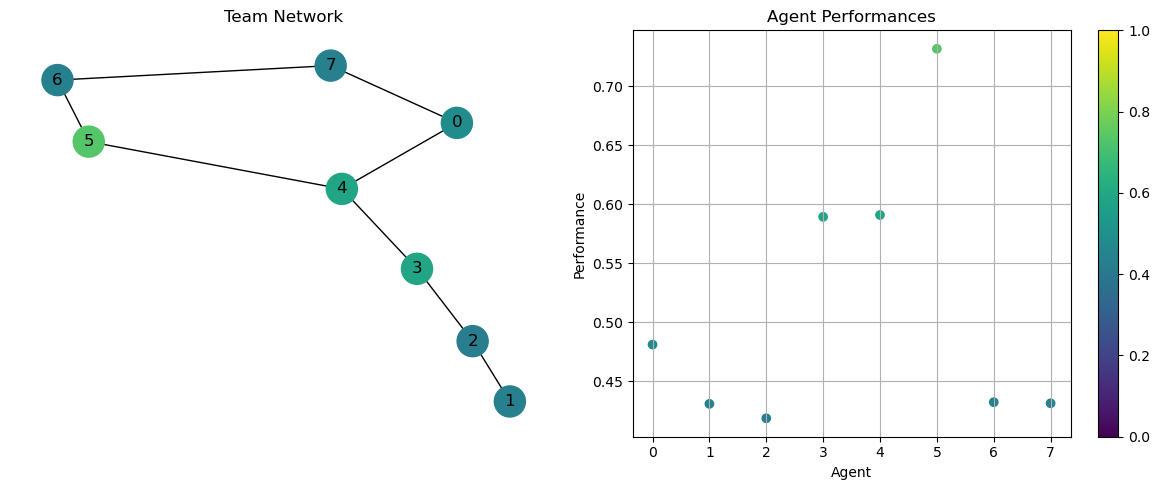

In [9]:
for name, team in teams.items():
    print(f"\n=== {name.upper()} TEAM ===")
    print(f"Number of nodes: {team.number_of_nodes()}")
    print(f"Number of edges: {team.number_of_edges()}")
    print(f"Initial performance: {team.get_team_fx():.3f}")
    print("Network metrics:")
    for metric, value in team.network_metrics.items():
        if not np.isnan(value):
            print(f"  {metric}: {value:.3f}")
            
    # Plot initial state with node colors based on agent performance
    fig = plot_team_snapshot(team)
    plt.show()

## Team Evolution

Visualize how teams evolve over multiple steps:

In [10]:
# Animate evolution for each team type
for name, team in teams.items():
    print(f"\n=== {name.upper()} TEAM EVOLUTION ===")
    anim = visualize_team_evolution(team, steps=10)
    # Create HTML display object and show animation
    html = display.HTML(anim.to_jshtml())
    display.display(html)
    plt.close()  # Clean up figure after displaying


=== COMPLETE TEAM EVOLUTION ===



=== STAR TEAM EVOLUTION ===



=== SMALL_WORLD TEAM EVOLUTION ===


## Performance Comparison

Compare performance trajectories across different network structures:

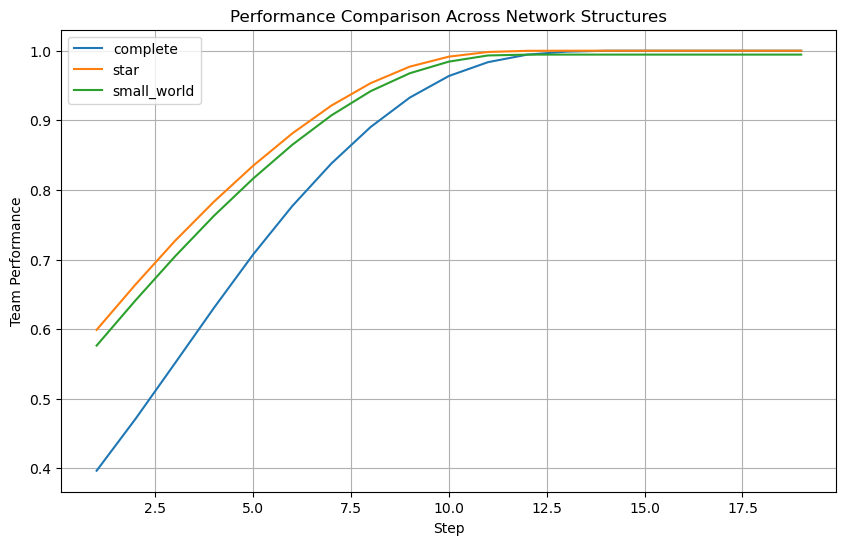

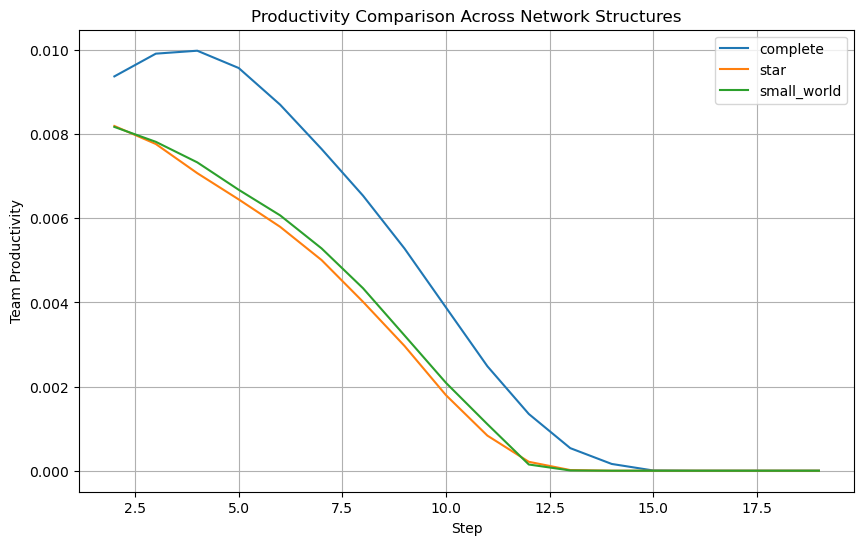

In [11]:
# Reset teams
teams = {
    'complete': Team(**base_params),
    'star': Team(**{**base_params, 'team_graph_type': 'star'}),
    'small_world': Team(**{**base_params, 
                          'team_graph_type': 'small_world',
                          'team_graph_opts': {'k': 2, 'p': 0.1},
                          'team_size': 8})
}

# Track performance and productivity over steps
steps = 20
performances = {name: [team.get_team_fx()] for name, team in teams.items()}
productivities = {name: [team.get_team_dfdt()] for name, team in teams.items()}

# Run simulation
for _ in range(steps-1):
    for name, team in teams.items():
        team.step()
        performances[name].append(team.get_team_fx())
        productivities[name].append(team.get_team_dfdt())

# Plot performance results
plt.figure(figsize=(10, 6))
for name, perf in performances.items():
    plt.plot(range(steps), perf, label=name)
plt.xlabel('Step')
plt.ylabel('Team Performance')
plt.title('Performance Comparison Across Network Structures')
plt.legend()
plt.grid(True)
plt.show()

# Plot productivity results
plt.figure(figsize=(10, 6))
for name, prod in productivities.items():
    plt.plot(range(steps), prod, label=name)
plt.xlabel('Step')
plt.ylabel('Team Productivity')
plt.title('Productivity Comparison Across Network Structures')
plt.legend()
plt.grid(True)
plt.show()

## Network Metric Analysis

Compare structural properties across networks:

In [13]:
# Compare key network metrics
metric_keys = [
    'team_graph_density',
    'team_graph_clustering',
    'team_graph_assortativity',
    'team_graph_pathlength',
    'team_graph_diameter'
]

print("Network Metric Comparison:")
print("\nMetric\t\t" + "\t".join(teams.keys()))
print("-" * 60)

for key in metric_keys:
    values = [f"{team.network_metrics.get(key, float('nan')):.3f}" for team in teams.values()]
    print(f"{key}:\t" + "\t".join(values))

Network Metric Comparison:

Metric		complete	star	small_world
------------------------------------------------------------
team_graph_density:	1.000	0.250	0.286
team_graph_clustering:	1.000	0.000	0.000
team_graph_assortativity:	0.000	-1.000	0.000
team_graph_pathlength:	1.000	1.750	2.286
team_graph_diameter:	1.000	2.000	4.000


## Analysis of Results

Key observations:
1. Network structure effects:
   - Complete network: All agents directly connected, rapid information flow
   - Star network: Central agent influences all others
   - Small world: Balance of local clusters and global connections
   
2. Performance patterns:
   - Initial convergence speed
   - Final performance levels
   - Stability of solutions
   
3. Agent behavior:
   - Individual vs. collective performance
   - Local vs. global optimization
   - Network position effects
   
4. Variable distribution effects:
   - Each agent controls multiple variables
   - Coordination through neighborhood objectives
   - Balance between independence and interdependence